# 데이터 Overview 노트북

`sp500_macro_master.csv` 데이터를 대상으로 전반적인 구조, 결측치, 분포, 상관관계, 시계열 트렌드를 빠르게 파악하기 위한 탐색용 노트북입니다.

- 사용 라이브러리: `pandas`, `seaborn`, `matplotlib`
- 목적: 모델링 전 데이터 품질 및 패턴 점검

In [ ]:
import os
os.chdir("/home/pj/dev/HFM_Implementation")
print(os.getcwd())

/home/pj/dev/HFM_Implementation


In [2]:
import sys
import subprocess
import importlib

import pandas as pd
import matplotlib.pyplot as plt

if importlib.util.find_spec("seaborn") is None:
    print("seaborn 미설치 상태입니다. 현재 커널에 설치를 시도합니다...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "현재 커널에서 seaborn 자동 설치에 실패했습니다.\n"
            "노트북 Kernel 메뉴에서 사용 중인 커널을 바꾸거나, 터미널에서 커널 환경에 seaborn을 설치한 뒤 다시 실행하세요."
        ) from exc

import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
print("Python:", sys.executable)

Python: /home/pj/dev/miniconda3/envs/hfm-data/bin/python


In [5]:
DATA_PATH = "data/sp500_macro_master.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"shape: {df.shape}")
df.head()

shape: (123505, 17)


,Date,Ticker,Close,Volume,Sector,Industry,DGS10,VIXCLS,UNRATE,CPIAUCSL,BAMLH0A0HYM2,T10Y2Y,UMCSENT,FEDFUNDS_RATE,M2_MONEY_SUPPLY,SOFR,INFLATION_RATE
0,2021-03-08,AAPL,113.334137,154376600.0,Technology,Consumer Electronics,1.59,25.47,6.1,264.847,3.57,1.42,84.9,0.07,19823.4,0.02,2.623646
1,2021-03-09,AAPL,117.941109,129525800.0,Technology,Consumer Electronics,1.55,24.03,6.1,264.847,3.62,1.38,84.9,0.07,19823.4,0.02,2.623646
2,2021-03-10,AAPL,116.859993,111943300.0,Technology,Consumer Electronics,1.53,22.56,6.1,264.847,3.63,1.37,84.9,0.07,19823.4,0.02,2.623646
3,2021-03-11,AAPL,118.788513,103026500.0,Technology,Consumer Electronics,1.54,21.91,6.1,264.847,3.52,1.40,84.9,0.07,19823.4,0.01,2.623646
4,2021-03-12,AAPL,117.882675,88105100.0,Technology,Consumer Electronics,1.64,20.69,6.1,264.847,3.55,1.50,84.9,0.07,19823.4,0.01,2.623646


In [6]:
df.info()

print("\nDate 범위:", df["Date"].min(), "~", df["Date"].max())
print("Ticker 개수:", df["Ticker"].nunique())
print("Sector 개수:", df["Sector"].nunique())
print("Industry 개수:", df["Industry"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123505 entries, 0 to 123504
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date             123505 non-null  datetime64[ns]
 1   Ticker           123505 non-null  object        
 2   Close            123505 non-null  float64       
 3   Volume           123505 non-null  float64       
 4   Sector           123505 non-null  object        
 5   Industry         123505 non-null  object        
 6   DGS10            123505 non-null  float64       
 7   VIXCLS           123505 non-null  float64       
 8   UNRATE           123505 non-null  float64       
 9   CPIAUCSL         123505 non-null  float64       
 10  BAMLH0A0HYM2     123505 non-null  float64       
 11  T10Y2Y           123505 non-null  float64       
 12  UMCSENT          123505 non-null  float64       
 13  FEDFUNDS_RATE    123505 non-null  float64       
 14  M2_MONEY_SUPPLY  123

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_ratio(%)": missing_ratio})

missing_table[missing_table["missing_count"] > 0].head(30)

,missing_count,missing_ratio(%)


In [8]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in ["Ticker", "Sector", "Industry"] if c in df.columns]

display(df[numeric_cols].describe().T)

for col in cat_cols:
    display(df[col].value_counts().head(20).to_frame(name="count"))

,count,mean,std,min,25%,50%,75%,max
Close,123505.0,2.345262e+02,3.736598e+02,6.000000,8.865249e+01,1.562300e+02,2.747900e+02,5.781648e+03
Volume,123505.0,1.605527e+07,4.625129e+07,52800.000000,2.693100e+06,5.671100e+06,1.368350e+07,1.543911e+09
DGS10,123505.0,3.477479e+00,1.080413e+00,1.190000,2.880000e+00,3.970000e+00,4.270000e+00,4.980000e+00
VIXCLS,123505.0,1.912609e+01,5.189036e+00,11.860000,1.548000e+01,1.788000e+01,2.157000e+01,5.233000e+01
UNRATE,123505.0,4.117067e+00,6.243866e-01,3.400000,3.700000e+00,4.000000e+00,4.300000e+00,6.100000e+00
CPIAUCSL,123505.0,3.031181e+02,1.738219e+01,264.847000,2.949400e+02,3.073740e+02,3.176030e+02,3.265880e+02
BAMLH0A0HYM2,123505.0,3.595019e+00,7.122950e-01,2.590000,3.080000e+00,3.330000e+00,4.100000e+00,5.990000e+00
T10Y2Y,123505.0,1.540424e-01,6.540804e-01,-1.080000,-3.900000e-01,1.500000e-01,5.800000e-01,1.590000e+00
UMCSENT,123505.0,6.558283e+01,9.168550e+00,50.000000,5.840000e+01,6.490000e+01,7.060000e+01,8.830000e+01
FEDFUNDS_RATE,123505.0,3.406529e+00,2.042010e+00,0.060000,1.210000e+00,4.330000e+00,5.120000e+00,5.330000e+00


,count
Ticker,
AAPL,1256
ADBE,1256
ACN,1256
DHR,1256
ETN,1256
ADI,1256
ADP,1256
AMAT,1256
AMD,1256


,count
Sector,
Technology,28874
Financial Services,22600
Healthcare,21340
Industrials,12552
Consumer Cyclical,11294
Communication Services,11292
Consumer Defensive,7532
Energy,3766
Utilities,1743


,count
Industry,
Drug Manufacturers - General,10044
Semiconductors,8790
Software - Infrastructure,6276
Software - Application,6276
Banks - Diversified,5022
Aerospace & Defense,5022
Medical Devices,5020
Telecom Services,5020
Capital Markets,3768


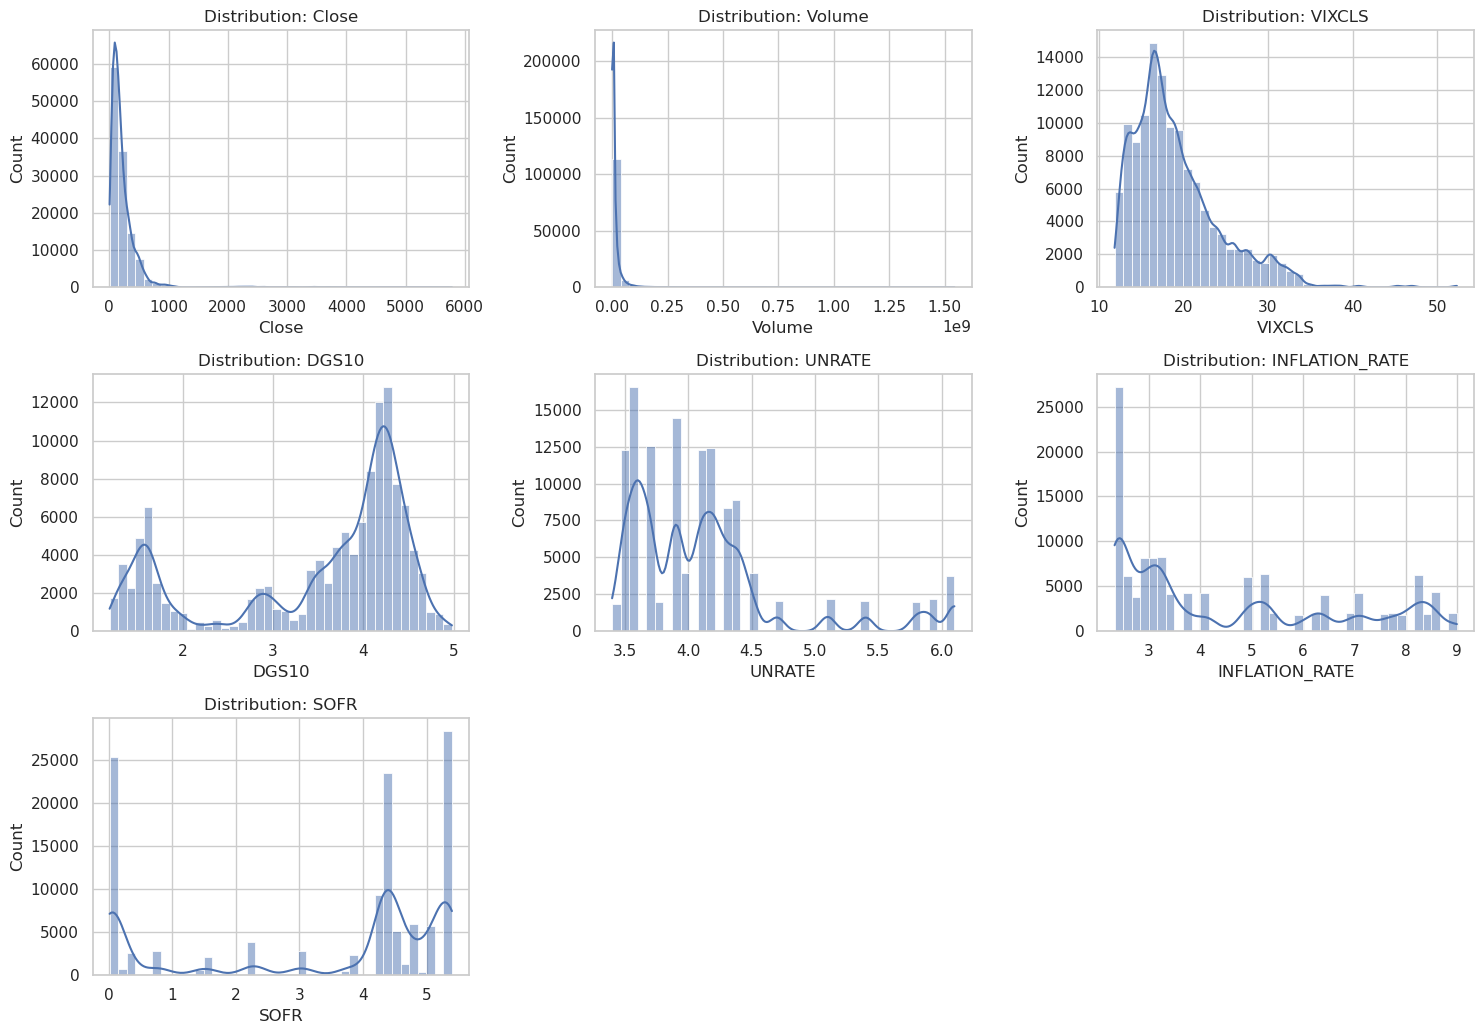

In [9]:
plot_candidates = ["Close", "Volume", "VIXCLS", "DGS10", "UNRATE", "INFLATION_RATE", "SOFR"]
plot_cols = [c for c in plot_candidates if c in df.columns]

if plot_cols:
    n = len(plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        sns.histplot(df[col].dropna(), kde=True, bins=40, ax=axes[i], color="#4C72B0")
        axes[i].set_title(f"Distribution: {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("시각화 가능한 숫자 컬럼이 없습니다.")

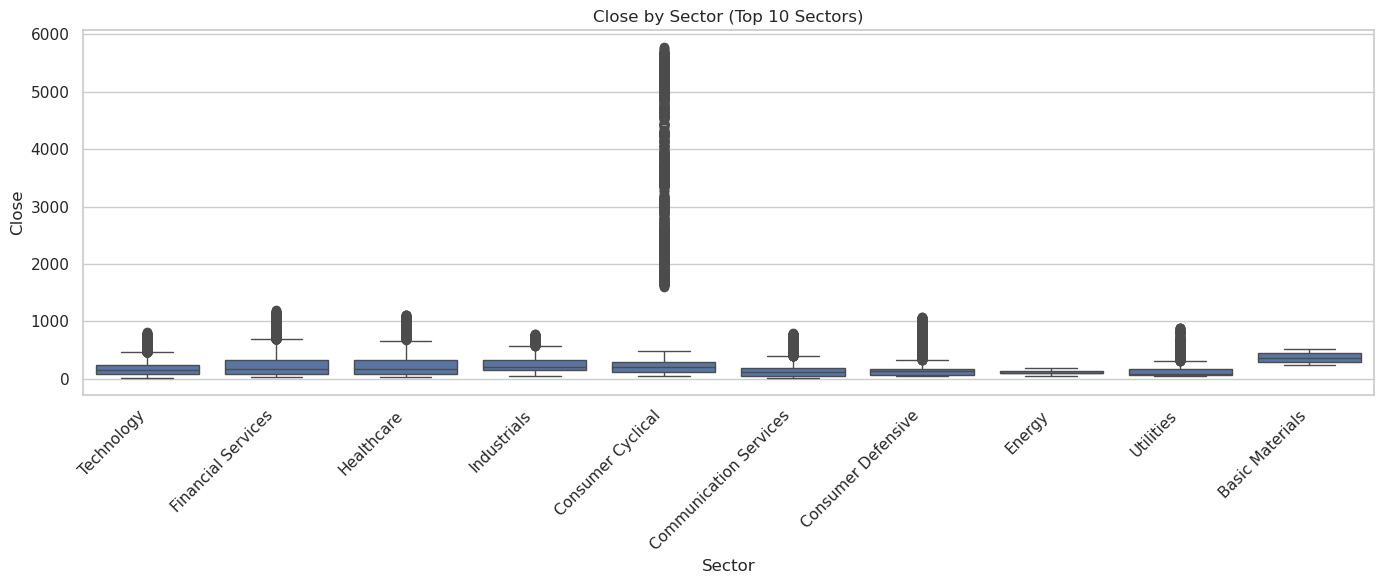

In [10]:
if {"Sector", "Close"}.issubset(df.columns):
    top_sectors = df["Sector"].value_counts().head(10).index
    subset = df[df["Sector"].isin(top_sectors)].copy()

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=subset, x="Sector", y="Close", order=top_sectors)
    plt.xticks(rotation=45, ha="right")
    plt.title("Close by Sector (Top 10 Sectors)")
    plt.tight_layout()
    plt.show()
else:
    print("Sector/Close 컬럼이 없어 박스플롯을 생략합니다.")

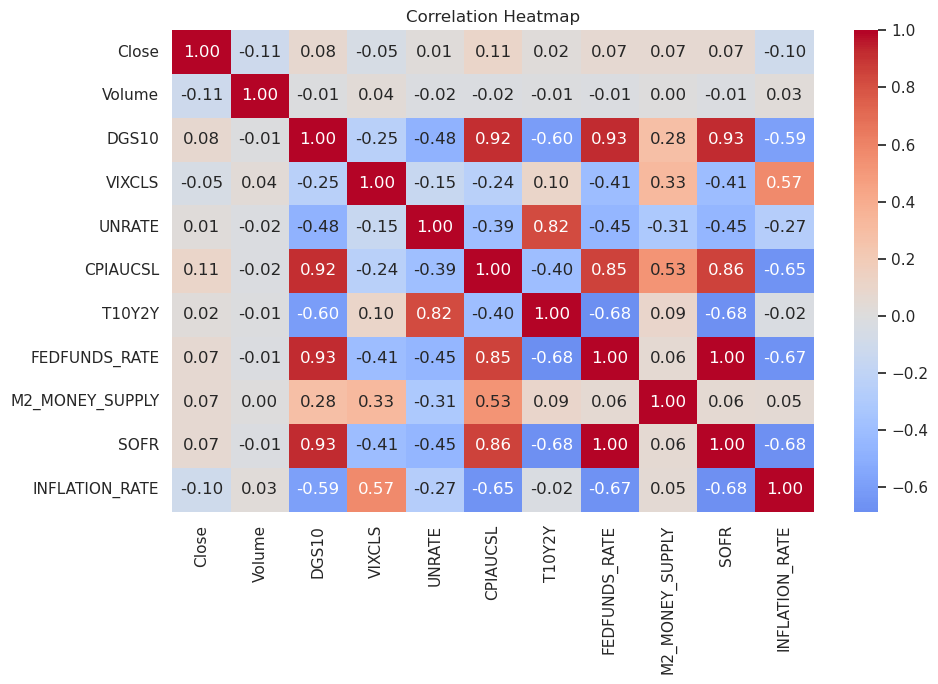

In [11]:
corr_candidates = ["Close", "Volume", "DGS10", "VIXCLS", "UNRATE", "CPIAUCSL", "T10Y2Y", "FEDFUNDS_RATE", "M2_MONEY_SUPPLY", "SOFR", "INFLATION_RATE"]
corr_cols = [c for c in corr_candidates if c in df.columns]

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("상관관계를 계산할 컬럼 수가 부족합니다.")

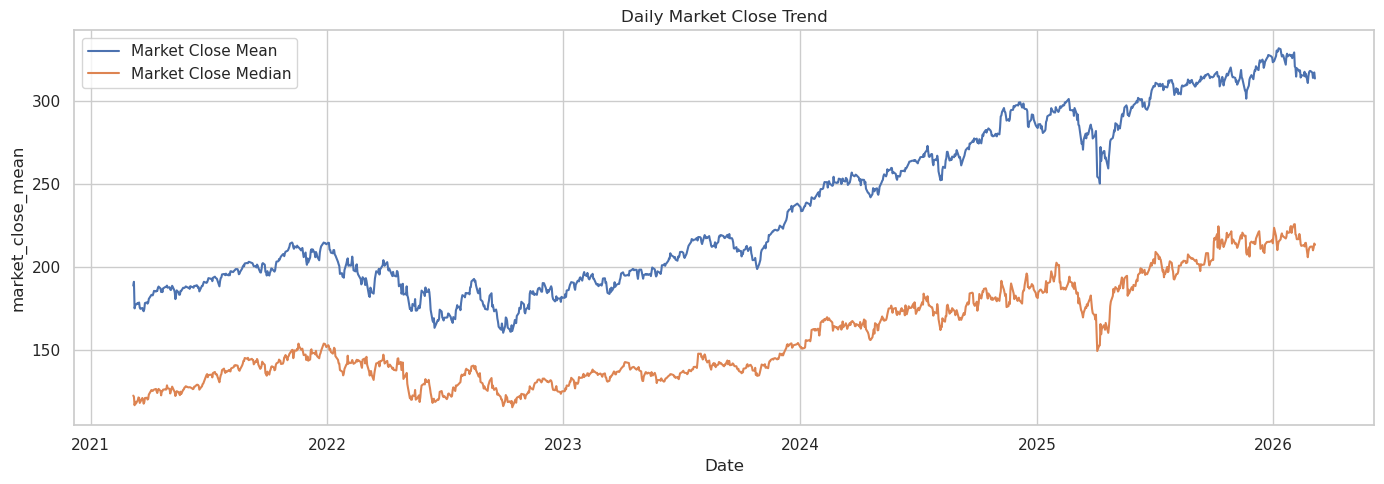

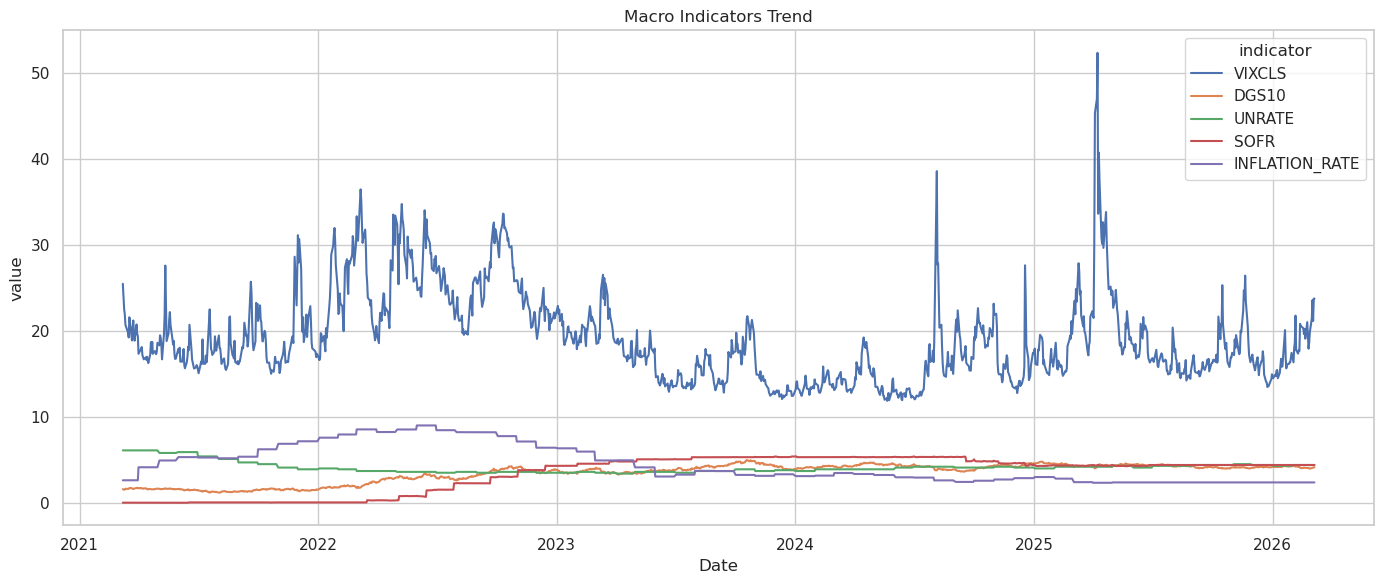

In [12]:
daily = df.sort_values("Date").groupby("Date", as_index=False).agg(
    market_close_mean=("Close", "mean"),
    market_close_median=("Close", "median")
)

macro_cols = [c for c in ["VIXCLS", "DGS10", "UNRATE", "SOFR", "INFLATION_RATE"] if c in df.columns]
macro_daily = df.sort_values("Date").groupby("Date", as_index=False)[macro_cols].mean() if macro_cols else None

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="Date", y="market_close_mean", label="Market Close Mean")
sns.lineplot(data=daily, x="Date", y="market_close_median", label="Market Close Median")
plt.title("Daily Market Close Trend")
plt.tight_layout()
plt.show()

if macro_daily is not None and len(macro_cols) > 0:
    melted = macro_daily.melt(id_vars="Date", var_name="indicator", value_name="value")
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=melted, x="Date", y="value", hue="indicator")
    plt.title("Macro Indicators Trend")
    plt.tight_layout()
    plt.show()

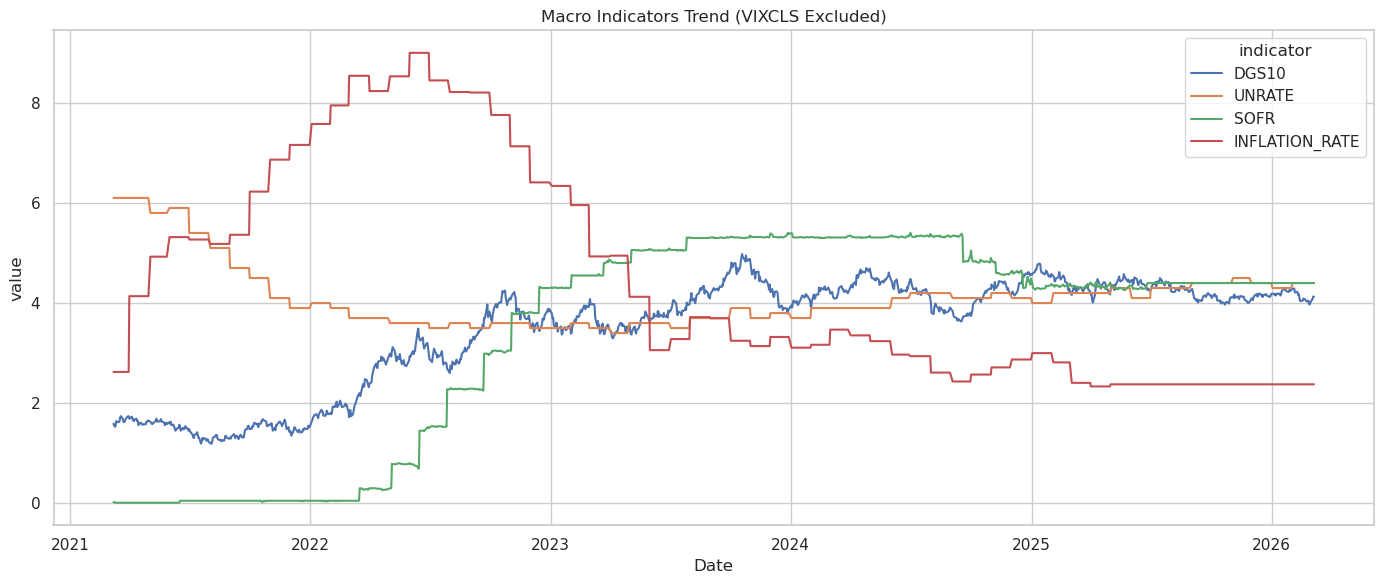

In [13]:
if macro_daily is not None and len(macro_cols) > 0:
    # VIXCLS 제외한 인디케이터만 시각화
    indicators_no_vixcls = [col for col in macro_cols if col != "VIXCLS"]
    if indicators_no_vixcls:
        melted_no_vixcls = macro_daily.melt(id_vars="Date", value_vars=indicators_no_vixcls, var_name="indicator", value_name="value")
        plt.figure(figsize=(14, 6))
        sns.lineplot(data=melted_no_vixcls, x="Date", y="value", hue="indicator")
        plt.title("Macro Indicators Trend (VIXCLS Excluded)")
        plt.tight_layout()
        plt.show()
    else:
        print("VIXCLS을 제외하면 시각화할 macro indicator가 없습니다.")

## 점검 포인트

- 결측치가 많은 컬럼은 학습 전 보간/제거 전략 필요
- 분포가 긴 꼬리를 가지는 변수는 로그 변환 고려
- 강한 상관관계 변수는 다중공선성 점검
- 시계열 추세 변화가 큰 구간은 레짐 분리/피처 엔지니어링 검토